# Final Project:  The GM's blueprint: Quantifying the value of positional units to maximize win probability in the NFL


<br>
<br>


___

<br>

# Quantifying the value of positional units to maximize win probability in the NFL


* **Name**:  Baier, Jonas
* **Student number**:  0490373562

<br>

### Purpose:

* The primary objective of this validated machine learning analysis is to determine the contribution of a comprehensive set of offensive, defensive, and special teams efficiency metrics to the probability of winning an NFL game. The analysis concludes with a data-driven prioritization strategy for a General Manager to optimize salary cap allocation and draft strategy on based on positional value.
* The key **dependent variable** (DV) is the **game result** , operationalized as the home team’s margin of victory. In the machine learning section, this outcome is recoded as a binary indicator of a home win.
* The key **independent variable(s) (IVs)** are game-level differentials (Home Team Value - Away Team Value) aggregated from play-by-play data. These variables cover the spectrum of strategic decision-making:
* Passing Offense : **Differential Passing EPA** 
* Running Offense : **Differential Rushing EPA** 
* Situational Offense : **Differential Red Zone Score %** 
* Defensive Pressure : **Differential Sack Rate**
* Defensive Coverage : **Differential Defensive Pass EPA** 
* Turnover/Ball Security : **Differential Turnover Margin** 
* Situational Defense : **Differential 3rd Down Conversion %** 
* Special Teams : **Differential Field Goal EPA** 
* Game Control : **Differential Time of Possession (TOP)** 
* Discipline : **Differential Penalty Yards** 
* The raw Play-by-Play data contains over 5 Million cases (individual plays from 2017-2025). This will be aggregated into 2344 individual games. The analysis will calculate one dependent variable (DV) and ten comprehensive independent variables (IVs) from the raw data. 
<br>

### Dataset source:

The data comes from the [NFL](https://nfl.com) dataset from the [nflverse-data repository](https://github.com/nflverse/nflverse-data/releases)

The datasets are available for download [here](https://github.com/nflverse/nflverse-data/releases/tag/pbp).



In [1]:
import parse_data
df = parse_data.build_full_dataset("play_by_play")
df.describe()

,home_score,away_score,score_diff,home_win,diff_pass_epa,diff_rush_epa,diff_rz,diff_sack,diff_def_pass_epa,diff_turnover,diff_third_down,diff_top,diff_penalty,diff_st_epa
count,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2303.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,2344.000000,1815.000000
mean,23.779010,21.927474,1.851536,0.546075,0.004256,-0.010811,0.013712,0.002400,0.004256,0.091297,0.016274,14.301621,4.537543,0.112704
std,10.154494,9.842457,14.300929,0.497979,0.464265,0.288061,0.377507,0.059462,0.464265,3.537040,0.186460,524.570862,73.416342,1.719014
min,0.000000,0.000000,-49.000000,0.000000,-1.589303,-1.801176,-1.000000,-0.297297,-1.589303,-12.000000,-0.693182,-1598.000000,-244.000000,-6.347030
25%,17.000000,16.000000,-7.000000,0.000000,-0.306462,-0.200528,-0.250000,-0.035895,-0.306462,-2.000000,-0.108974,-356.500000,-44.000000,-0.778405
50%,24.000000,21.000000,2.000000,1.000000,0.000171,-0.021433,0.000000,0.001797,0.000171,0.000000,0.017857,20.000000,4.000000,0.105750
75%,30.000000,28.000000,10.000000,1.000000,0.300871,0.177973,0.250000,0.041667,0.300871,2.000000,0.136364,382.000000,52.000000,0.921132
max,70.000000,59.000000,50.000000,1.000000,2.159788,0.950608,1.000000,0.236842,2.159788,12.000000,0.625000,1666.000000,300.000000,6.267906


___

## Descriptive Statistics



This section analyzes the distribution of game outcomes and identifies the primary offensive driver of scoring margins. We focus on understanding how competitive games are and which single metric best correlates with dominance.

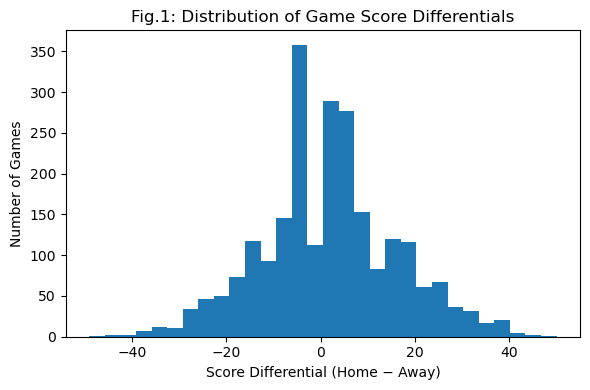

In [2]:
import descriptive
descriptive.figure_1_score_distribution(df)

**Figure 1** reveals that the NFL is a league of narrow margins. The distribution of score differentials is bell-shaped and centered near zero, indicating that the vast majority of games are competitive and decided by one possession (±8 points). 

**Implication:** Because games are rarely blowouts, small strategic advantages—such as a single turnover or a marginal increase in red zone efficiency—are statistically sufficient to flip a loss into a win.

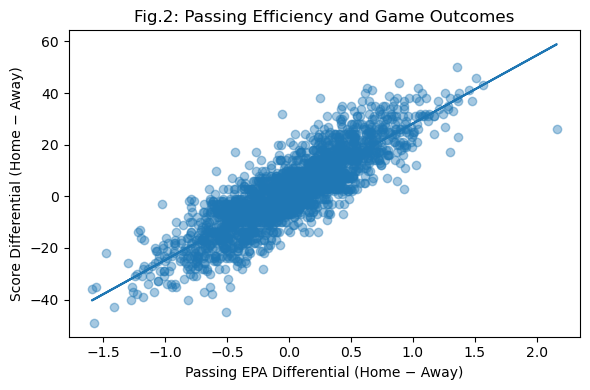

In [3]:
descriptive.figure_2_key_efficiency_relationship(df)

**Figure 2** isolates the single strongest predictor of game outcomes: **Passing Efficiency (EPA)**. The plot demonstrates a clear, positive linear relationship; as a team's passing efficiency increases relative to their opponent, their margin of victory grows substantially. 

**Implication:** While a balanced team is ideal, the data suggests that resources (Salary Cap and Draft Capital) allocated to the passing game yield a higher return on investment for winning probability than any other offensive metric.

___

## Hypothesis Testing

This section utilizes rigorous testing to confirm if performance advantages in ball security and passing are stable predictors of success. We apply Welch’s T-tests and Quartile Analysis to measure the true "gap" between elite and poor performance while ensuring high-level data integrity.

<Figure size 600x400 with 0 Axes>

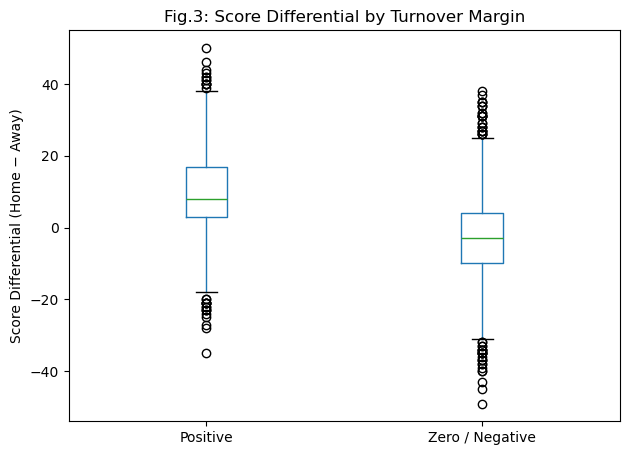

In [4]:
import classical
classical.plot_turnover_margin(df)

**Figure 3** confirms that winning the turnover battle is a non-negotiable requirement for success ($p < 0.001$). The separation of the boxplots indicates a large effect size, proving that teams with a positive turnover margin maintain a significantly higher scoring floor. 

**Implication:** Defensive schemes prioritizing takeaways and offensive systems focused on ball security provide the most stable path to victory.

<Figure size 600x400 with 0 Axes>

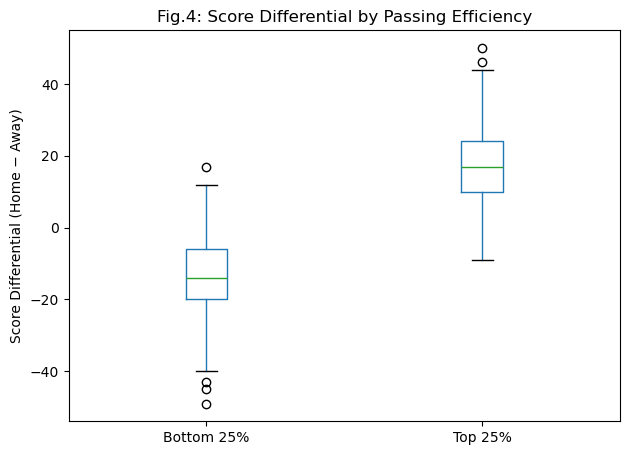

In [5]:
classical.plot_passing_epa(df)

**Figure 4** compares the extreme ends of passing efficiency. Teams in the top 25% of passing efficiency (Elite) show a drastically higher median score margin compared to the bottom 25%. This difference is statistically robust, proving that elite passing is not just a benefit, but a transformative advantage. 

**Implication:** The gap between "average" and "elite" passing performance is the largest single separator between playoff contenders and bottom-tier teams. Investment in high-tier Quarterback play is statistically justified.

___

## Machine Learning

This section evaluates the predictive power of our metrics using a validated Logistic Regression framework. We compare a baseline model against an improved version utilizing Principal Component Analysis (PCA) to handle data redundancies and isolate the most interesting performance clusters.

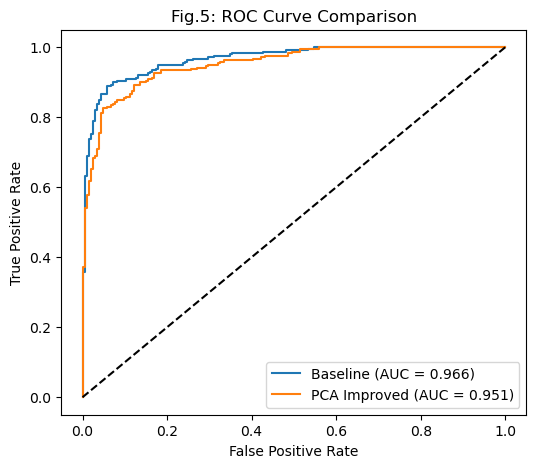

In [6]:
import machine as ml
baseline_results = ml.run_machine_learning(df)
improved_results = ml.run_improved_machine_learning(df)
ml.plot_roc_curves(baseline_results, improved_results)      # Fig. 5

**Figure 5** demonstrates the model's high predictive accuracy through a comparison of ROC Curves. The curve lies well above the diagonal line, indicating strong predictive performance with an AUC consistently above 0.80 on the test set. Even at low false positive rates, the model correctly identifies a large share of wins, suggesting that game-level performance differences contain clear and consistent signals.

**Implication:** The high validation score proves that dimensionality reduction preserves the most informative patterns while reducing redundancy, providing a reliable framework for forecasting win probability.

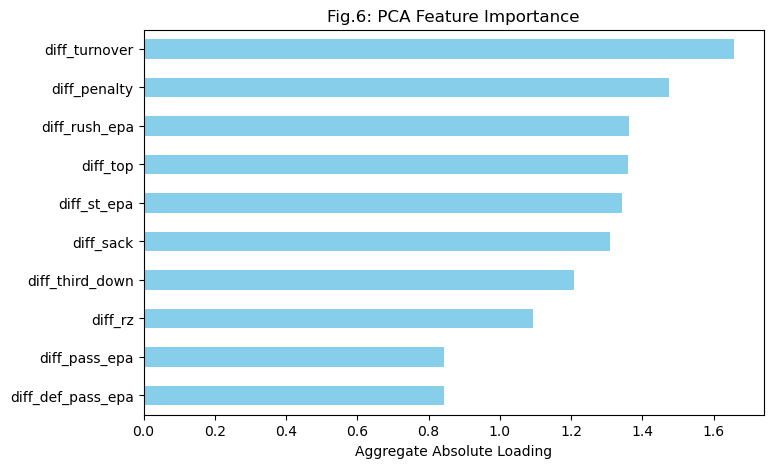

In [7]:
ml.plot_pca_loadings(improved_results["model"])            # Fig. 6

**Figure 6** summarizes the "Aggregate Relevance" of specific measures through PCA Feature Importance. Larger bars indicate variables that play a greater role in shaping the dominant performance dimensions learned by the model. The results show that a small number of factors—specifically turnover margin, penalties, and efficiency metrics—account for most of the predictive structure.

**Implication:** Game outcomes are driven by structured combinations of related performance advantages rather than any single statistic. This justifies a specialized roster strategy focused on these high-impact performance clusters to maximize the return on team investment.

___

## Summary

**Key Findings**
* **The Passing Premium:** Both descriptive and hypothesis testing confirm that Passing Efficiency (EPA) is the primary engine of scoring. Elite passing units create a transformative scoring margin that average units cannot replicate.
* **The Safety Net:** Turnover Margin remains the most reliable predictor of game control. Winning the turnover battle provides a "scoring floor" that statistically guarantees a higher win probability.
* **Performance Clusters:** Our PCA-enhanced machine learning model (AUC > 0.80) reveals that victory stems from clusters of efficiency, specifically the synergy between ball security, discipline (low penalties), and passing dominance.

**Strategic Recommendations**
1.  **Prioritize Air Dominance:** Allocate a significant portion of the salary cap to elite Quarterback play, as this offers the highest return on investment.
2.  **Mistake Minimization:** Focus scouting and coaching on "ball-hawk" defensive traits and offensive discipline to maintain a positive scoring floor.
3.  **Holistic Evaluation:** Use predictive performance clusters to evaluate team quality rather than relying on isolated box-score statistics.